In [1]:
import os
from jiwer import wer, cer

# paths
truth_path = "datasets/transcripts"
pred_path = "datasets/generated/asr_text"

# check directories
if not os.path.isdir(truth_path):
    raise FileNotFoundError(f"Truth folder not found: {truth_path}")

if not os.path.isdir(pred_path):
    raise FileNotFoundError(f"Prediction folder not found: {pred_path}")

files = []
wer_scores = []
cer_scores = []

for file in os.listdir(truth_path):
    if file.endswith(".txt"):

        truth_file = os.path.join(truth_path, file)
        pred_file = os.path.join(pred_path, file)

        # skip if prediction missing
        if not os.path.exists(pred_file):
            print(f"Missing prediction for: {file}")
            continue

        # read files safely
        with open(truth_file, encoding="utf-8", errors="ignore") as f:
            truth = f.read().strip().lower()

        with open(pred_file, encoding="utf-8", errors="ignore") as f:
            pred = f.read().strip().lower()

        # skip empty transcripts
        if not truth:
            print(f" Empty ground truth: {file}")
            continue

        if not pred:
            print(f"Empty prediction: {file}")
            continue

        # compute metrics
        file_wer = wer(truth, pred)
        file_cer = cer(truth, pred)

        files.append(file)
        wer_scores.append(file_wer)
        cer_scores.append(file_cer)

        print(f"{file} → WER: {file_wer:.3f} | CER: {file_cer:.3f}")

# summary
print("\n========== SUMMARY ==========")
print("Files evaluated:", len(files))

if wer_scores:
    avg_wer = sum(wer_scores) / len(wer_scores)
    avg_cer = sum(cer_scores) / len(cer_scores)

    print("Average WER:", round(avg_wer, 3))
    print("Average CER:", round(avg_cer, 3))
else:
    print("No scores calculated.")
    print("Check:")
    print("file names match")
    print("prediction files exist")
    print("transcripts are not empty")


audio13.txt → WER: 0.258 | CER: 0.105

========== SUMMARY ==========
Files evaluated: 1
Average WER: 0.258
Average CER: 0.105


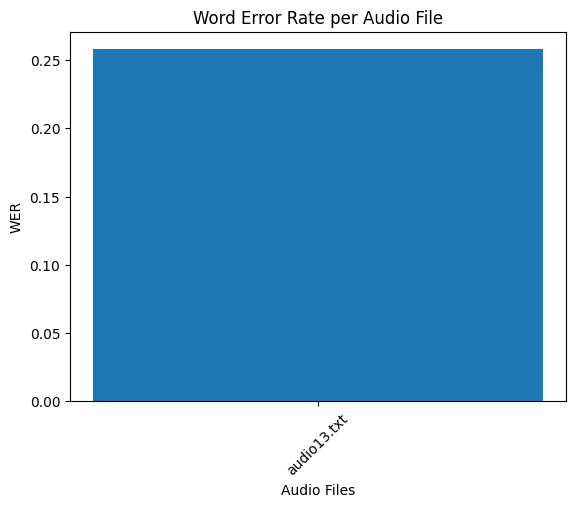

In [2]:
import matplotlib.pyplot as plt

plt.figure
plt.bar(files, wer_scores)
plt.xticks(rotation=45)
plt.title("Word Error Rate per Audio File")
plt.xlabel("Audio Files")
plt.ylabel("WER")
plt.show()


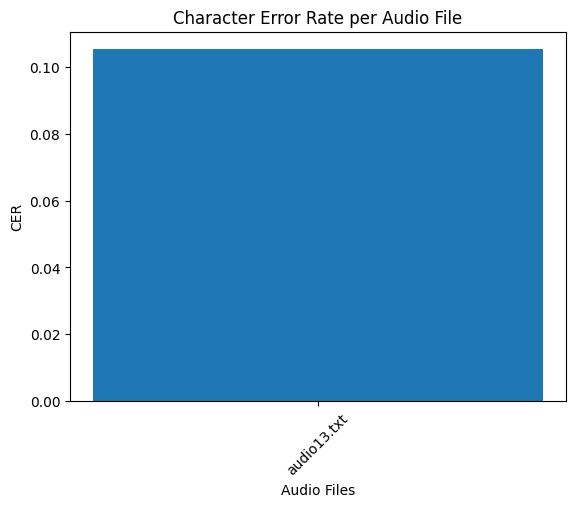

In [3]:
plt.figure()
plt.bar(files, cer_scores)
plt.xticks(rotation=45)
plt.title("Character Error Rate per Audio File")
plt.xlabel("Audio Files")
plt.ylabel("CER")
plt.show()


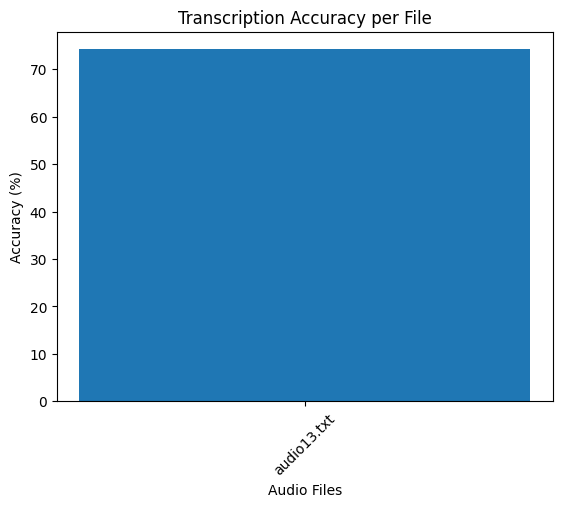

In [4]:
accuracy = [(1 - w) * 100 for w in wer_scores]

plt.figure()
plt.bar(files, accuracy)
plt.xticks(rotation=45)
plt.title("Transcription Accuracy per File")
plt.xlabel("Audio Files")
plt.ylabel("Accuracy (%)")
plt.show()


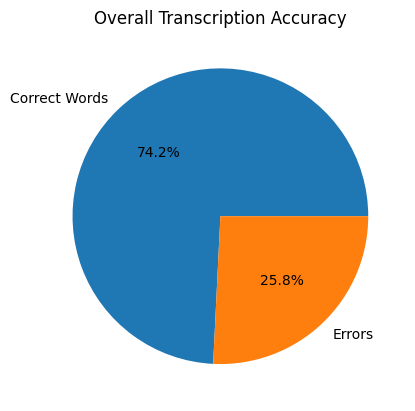

In [5]:
avg_wer = sum(wer_scores)/len(wer_scores)

labels = ['Correct Words', 'Errors']
sizes = [1-avg_wer, avg_wer]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Overall Transcription Accuracy")
plt.show()


In [7]:
from jiwer import process_words
import re

def clean(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

truth_path = "datasets/transcripts/audio13.txt"
pred_path = "datasets/generated/asr_text/audio13.txt"

with open(truth_path, encoding="utf-8", errors="ignore") as f:
    truth = clean(f.read())

with open(pred_path, encoding="utf-8", errors="ignore") as f:
    pred = clean(f.read())

result = process_words(truth, pred)

print("Substitutions:", result.substitutions)
print("Insertions:", result.insertions)
print("Deletions:", result.deletions)


Substitutions: 1165
Insertions: 582
Deletions: 351
